## Ejercicio 3: Inspección visual de un producto

### Ficha PEAS

| Elemento | Descripción |
|---|---|
| Percepción (S) | Matriz NumPy de 5x5 píxeles, donde 0 representa un píxel normal y 1 un píxel defectuoso |
| Acciones (A) | Aprobar el producto, enviarlo a revisión manual o rechazarlo |
| Entorno (E) | Línea de producción industrial con cámara de inspección |
| Objetivo | Detectar productos con defectos visuales y tomar una decisión adecuada |
| Medida de desempeño (P) | Identificar correctamente los productos defectuosos y reducir errores de inspección |

### Justificación de las reglas

Las reglas serán las siguientes:

- Si el producto tiene 0 píxeles defectuosos, se aprueba.
- Si tiene entre 1 y 3 píxeles defectuosos, se envía a revisión manual.
- Si tiene más de 3 píxeles defectuosos, se rechaza.

Estas reglas permiten aprobar automáticamente productos sin defectos, revisar manualmente los casos con pocos defectos y rechazar aquellos con una cantidad mayor de anomalías.

### Código

In [1]:
import numpy as np

def agente_inspeccion(imagen):
    """
    Percepción (S): matriz 5x5 de NumPy
    0 = píxel normal
    1 = píxel defectuoso
    """

    defectos = np.sum(imagen == 1)

    if defectos == 0:
        return "aprobar", "no se detectaron píxeles defectuosos"

    elif defectos <= 3:
        return "revisión manual", f"se detectaron {defectos} píxeles defectuosos"

    else:
        return "rechazar", f"se detectaron {defectos} píxeles defectuosos"

### Simulación y pruebas

In [2]:
imagen_0 = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
])

imagen_1 = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
])

imagen_3 = np.array([
    [1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
])

imagen_4 = np.array([
    [1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0]
])

In [3]:
imagenes = [
    ("Imagen con 0 defectos", imagen_0),
    ("Imagen con 1 defecto", imagen_1),
    ("Imagen con 3 defectos", imagen_3),
    ("Imagen con 4 defectos", imagen_4)
]

for nombre, imagen in imagenes:
    print(nombre)
    print(imagen)
    print("Resultado:", agente_inspeccion(imagen))
    print("-" * 50)

Imagen con 0 defectos
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Resultado: ('aprobar', 'no se detectaron píxeles defectuosos')
--------------------------------------------------
Imagen con 1 defecto
[[0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Resultado: ('revisión manual', 'se detectaron 1 píxeles defectuosos')
--------------------------------------------------
Imagen con 3 defectos
[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Resultado: ('revisión manual', 'se detectaron 3 píxeles defectuosos')
--------------------------------------------------
Imagen con 4 defectos
[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]]
Resultado: ('rechazar', 'se detectaron 4 píxeles defectuosos')
--------------------------------------------------


### Visualización

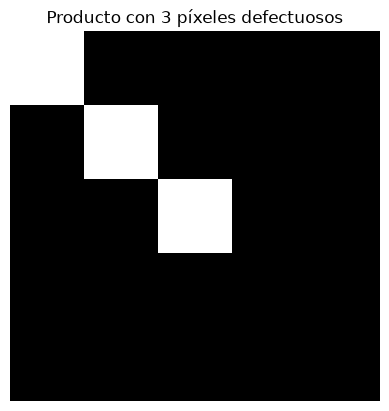

In [4]:
import matplotlib.pyplot as plt

plt.imshow(imagen_3, cmap="gray")
plt.title("Producto con 3 píxeles defectuosos")
plt.axis("off")
plt.show()